# Post-processing: truss results

## Strut'n'Tie — LUSAS LPI Course Series  
### Videos 06 & 07 

**Author:** Kamil Riedel  
**© Strut'n'Tie**  
**License:** MIT Licence

# Assumptions

**ULS load combination:**

$F_{Ed} = 1.35(F_{SW} + F_{DL}) + 1.50F_{LL}$

**Member resistances:**

Yield resistance:

$F_y = f_y A$

Tensile resistance:

$F_{Rd,t} = F_y$

Euler buckling resistance:

$F_{cr} = \frac{\pi^2 E I}{L^2}$

Compressive resistance:

$F_{Rd,c} = \min(F_y, F_{cr})$

**Utilisation:**

$\eta_{signed} = \frac{F_{Ed}}{F_{Rd}}$

$\eta_{absolute} = \frac{|F_{Ed}|}{F_{Rd}}$

# Connect to LUSAS

In [1]:
from shared.LPI import *
import shared.Helpers as Helpers
import pandas as pd
import numpy as np

modeller = get_lusas_modeller()
Helpers.initialise(modeller)

if not modeller.existsDatabase():
    raise Exception("A model must be open before running this code")

database = modeller.database()

modeller.getTextWindow().writeLine("Hello World")

# String constants

In [2]:
# Loadcase names as defined in the LUSAS model
LOADCASE_SW = "Self-weight"
LOADCASE_DL = "Dead load"
LOADCASE_LL = "Live load"

# DataFrame column names
LINE_ID = "Line ID"
SECTION_NAME = "Section name"
AREA = "Area"
I_YY = "Iyy"
I_ZZ = "Izz"
LENGTH = "Length"
ELEMENT_ID = "Element ID"
F_ED = "F_Ed"
F_RD = "F_Rd"
F_RD_TENSION = "F_Rd_t"
F_RD_COMPRESSION = "F_Rd_c"
UTILISATION_SIGNED = "Utilisation signed"
UTILISATION_ABSOLUTE = "Utilisation absolute"

# Helper functions

In [3]:
# Euclidean line length
def line_length(startX,startY,startZ,endX,endY,endZ):  
    dx = endX - startX
    dy = endY - startY
    dz = endZ - startZ
    return np.sqrt(dx*dx + dy*dy + dz*dz)

# Extract data

## Geometric sections

In [4]:
# ================================================================== #
# Geometric properties from database
# DF: Section name - Area - Iyy - Izz
attributes = database.getAttributes("Geometric")

# attr = attributes[0]
# print(f"attribute name: {attr.getName()}\n")
# print("Value names:")
# for value_name in attr.getValueNames():
#     print(value_name)

data = []

for attr in attributes:
    data.append({SECTION_NAME: attr.getName(), AREA: attr.getValue("A"), I_YY: attr.getValue("Iyy"), I_ZZ: attr.getValue("Izz")})

sections_df = pd.DataFrame(data)
sections_df

,Section name,Area,Iyy,Izz
0,top chord,0.009310,0.000114,0.000039
1,bottom chord,0.009310,0.000114,0.000039
2,diagonals,0.003826,0.000017,0.000006


## Lines

In [5]:
# ================================================================== #
# Line properties
# DF: Line - Section - Length
lines = database.getObjects("Lines")

data = []

for line in lines:
    lineID = line.getName()
    sections = line.getAssignments("Geometric")
    section = sections[0].getAttribute()
    sectName = section.getName()
    # Line length
    startNode = line.getStartPoint()
    endNode = line.getEndPoint()
    startX,startY,startZ = startNode.getXYZ()
    endX,endY,endZ = endNode.getXYZ()
    length = line_length(startX,startY,startZ,endX,endY,endZ)
    data.append({LINE_ID: lineID, SECTION_NAME: sectName, LENGTH: length})

lines_df = pd.DataFrame(data)
lines_df

,Line ID,Section name,Length
0,1,bottom chord,3.000000
1,2,bottom chord,3.000000
2,3,bottom chord,3.000000
3,4,bottom chord,3.000000
4,5,bottom chord,3.000000
5,6,bottom chord,3.000000
6,7,bottom chord,3.000000
7,8,bottom chord,3.000000
8,9,bottom chord,3.000000
9,10,top chord,3.000000


## Elements

In [6]:
# ================================================================== #
# Create context and get loadcases

# Results context 
context = modeller.newResultsContext(None)
# Add all elements
elements = database.getObjects("Element")
context.getCalcResultsSet().add(elements)
# Get loadsets
loadcase_SW = database.getLoadset(LOADCASE_SW)
loadcase_DL = database.getLoadset(LOADCASE_DL)
loadcase_LL = database.getLoadset(LOADCASE_LL)
# Ways to set loadset
context.setActiveLoadset(1) # Set using a loadset ID
context.setActiveLoadset(loadcase_SW) # Set using a loadset reference

In [7]:
# Get individual element results - inefficient
element = elements[0]
context.setActiveLoadset(loadcase_DL)
fx = element.getInternalResults(0, "Force/Moment - Thick 3D Beam", "Fx", None, None, context)
print(fx)

# Get the results for all elements
results = database.getResultsComponentSet("Force/Moment - Thick 3D Beam", "Fx", "Internal", context)
i_fx = results.getComponentNumber("Fx") # Component number for Fx DOF
fx_SW = results.getInternalResults(i_fx, element, 0, None, None)
print(fx)

# Clear the results from memory
results = None

(160340.86535556245, None)
(160340.86535556245, None)


In [8]:
# ================================================================== #
# DF: Element ID - Line ID - F_Ed

data = []

# Get the internal point results for all beam elements
context.setActiveLoadset(loadcase_SW)
results_SW = database.getResultsComponentSet("Force/Moment - Thick 3D Beam", "Fx", "Internal", context)
context.setActiveLoadset(loadcase_DL)
results_DL = database.getResultsComponentSet("Force/Moment - Thick 3D Beam", "Fx", "Internal", context)
context.setActiveLoadset(loadcase_LL)
results_LL = database.getResultsComponentSet("Force/Moment - Thick 3D Beam", "Fx", "Internal", context)
i_fx = results_SW.getComponentNumber("Fx") # Component number for Fx DOF

for element in elements:
    fx_SW = results_SW.getInternalResults(i_fx, element, 0, None, None)
    fx_DL = results_DL.getInternalResults(i_fx, element, 0, None, None)
    fx_LL = results_LL.getInternalResults(i_fx, element, 0, None, None)
    fx_ULS = 1.35 * (fx_SW + fx_DL) + 1.5 * fx_LL
    data.append({ELEMENT_ID: element.getName(), LINE_ID: element.getFeature().getName(), F_ED: fx_ULS})


# Clear the results from memory
context, fx, results_SW, results_DL, results_LL = None, None, None, None, None 

element_df = pd.DataFrame(data)
element_df

,Element ID,Line ID,F_Ed
0,1,1,3.843514e+05
1,2,1,3.843514e+05
2,3,1,3.843514e+05
3,4,2,1.043541e+06
4,5,2,1.043541e+06
...,...,...,...
100,101,34,8.281269e+05
101,102,34,8.285246e+05
102,103,35,-8.472731e+05
103,104,35,-8.476708e+05


# Process results

In [9]:
# Add line resistance
# DF: Line ID - Section name - Length - Area - Iyy - Izz - F_Rd_t - F_Rd_c

fy = 355E6 # Pa
E = 205E9 # Pa

# Merge relevant section properties into line_df based on Section name
line_resistances = lines_df.merge(sections_df, on="Section name", how="left")

# Calculate resistance
resistances_tension = [fy * row[AREA] for index, row in line_resistances.iterrows()]

resistances_compression = [min(
        fy * row[AREA],
        np.pi**2 * E * row[I_YY] / row[LENGTH]**2,
        np.pi**2 * E * row[I_ZZ] / row[LENGTH]**2
    ) for index, row in line_resistances.iterrows()]

line_resistances[F_RD_TENSION] = resistances_tension
line_resistances[F_RD_COMPRESSION] = resistances_compression

line_resistances

,Line ID,Section name,Length,Area,Iyy,Izz,F_Rd_t,F_Rd_c
0,1,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
1,2,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
2,3,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
3,4,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
4,5,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
5,6,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
6,7,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
7,8,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
8,9,bottom chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06
9,10,top chord,3.000000,0.009310,0.000114,0.000039,3.305090e+06,3.305090e+06


In [10]:
# Retrieve tensile resistance for element 3
line_resistances.loc[line_resistances[LINE_ID] == "3", F_RD_TENSION].iloc[0]

np.float64(3305089.9449203773)

In [11]:
# Add element resistance
# DF: Element ID - Line ID - F_Ed - F_Rd_t - F_Rd_c - Utilisation signed - Utilisation absolute

# Merge relevant section properties into line_resistances based on Section name
element_resistances = element_df.merge(line_resistances[[LINE_ID, F_RD_TENSION, F_RD_COMPRESSION]], on=LINE_ID, how="left")

# Add utilisation
utilisation = [
    row[F_ED] / row[F_RD_TENSION] 
    if row[F_ED] > 0 
    else row[F_ED] / row[F_RD_COMPRESSION]
    for index, row in element_resistances.iterrows()
]

element_resistances[UTILISATION_SIGNED] = utilisation

# make absolute
absolute = [np.abs(element_resistances[UTILISATION_SIGNED])]

element_resistances[UTILISATION_ABSOLUTE] = np.abs(element_resistances[UTILISATION_SIGNED])

element_resistances

,Element ID,Line ID,F_Ed,F_Rd_t,F_Rd_c,Utilisation signed,Utilisation absolute
0,1,1,3.843514e+05,3.305090e+06,3.305090e+06,0.116291,0.116291
1,2,1,3.843514e+05,3.305090e+06,3.305090e+06,0.116291,0.116291
2,3,1,3.843514e+05,3.305090e+06,3.305090e+06,0.116291,0.116291
3,4,2,1.043541e+06,3.305090e+06,3.305090e+06,0.315738,0.315738
4,5,2,1.043541e+06,3.305090e+06,3.305090e+06,0.315738,0.315738
...,...,...,...,...,...,...,...
100,101,34,8.281269e+05,1.358337e+06,1.007972e+06,0.609662,0.609662
101,102,34,8.285246e+05,1.358337e+06,1.007972e+06,0.609955,0.609955
102,103,35,-8.472731e+05,1.358337e+06,1.007972e+06,-0.840572,0.840572
103,104,35,-8.476708e+05,1.358337e+06,1.007972e+06,-0.840967,0.840967


In [12]:
# Get maximum utilisation
crit_element_ID = int(element_resistances.loc[element_resistances[UTILISATION_ABSOLUTE].idxmax(), "Element ID"])
print(f"max utilisation = {max(element_resistances[UTILISATION_ABSOLUTE])*100:.2f}%; element ID = {crit_element_ID}")
element_resistances.loc[ element_resistances[UTILISATION_ABSOLUTE] == max(element_resistances[UTILISATION_ABSOLUTE]) ]

max utilisation = 84.18%; element ID = 52


,Element ID,Line ID,F_Ed,F_Rd_t,F_Rd_c,Utilisation signed,Utilisation absolute
51,52,18,-848466.297994,1.358337e+06,1.007972e+06,-0.841756,0.841756


In [13]:
# Get tonnage
density = 7850 # kg/m^3
mass = (line_resistances[LENGTH] * line_resistances[AREA]).sum() * density
print(f"tonnage = {mass:.2e} kg")

tonnage = 5.54e+03 kg


# Plot the results

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

In [15]:
# ================================================================== #
# Create a dictionary
# Key: Line ID
# Values : list(node IDs)
elements = database.getObjects("Elements")

element_nodes = {}

for element in elements:
    nodes = element.getNodes()
    nodes_IDs = [node.getName() for node in nodes]
    element_nodes[element.getName()] = nodes_IDs

element_nodes

{'1': ['1', '3'],
 '2': ['3', '4'],
 '3': ['4', '2'],
 '4': ['2', '9'],
 '5': ['9', '10'],
 '6': ['10', '8'],
 '7': ['8', '15'],
 '8': ['15', '16'],
 '9': ['16', '14'],
 '10': ['14', '21'],
 '11': ['21', '22'],
 '12': ['22', '20'],
 '13': ['20', '27'],
 '14': ['27', '28'],
 '15': ['28', '26'],
 '16': ['26', '33'],
 '17': ['33', '34'],
 '18': ['34', '32'],
 '19': ['32', '39'],
 '20': ['39', '40'],
 '21': ['40', '38'],
 '22': ['38', '45'],
 '23': ['45', '46'],
 '24': ['46', '44'],
 '25': ['44', '51'],
 '26': ['51', '52'],
 '27': ['52', '50'],
 '28': ['56', '58'],
 '29': ['58', '59'],
 '30': ['59', '57'],
 '31': ['57', '64'],
 '32': ['64', '65'],
 '33': ['65', '63'],
 '34': ['63', '70'],
 '35': ['70', '71'],
 '36': ['71', '69'],
 '37': ['69', '76'],
 '38': ['76', '77'],
 '39': ['77', '75'],
 '40': ['75', '82'],
 '41': ['82', '83'],
 '42': ['83', '81'],
 '43': ['81', '88'],
 '44': ['88', '89'],
 '45': ['89', '87'],
 '46': ['87', '94'],
 '47': ['94', '95'],
 '48': ['95', '93'],
 '49': ['93'

In [16]:
# ================================================================== #
# Create a dictionary
# Key: Node ID
# Values : (x, y)
nodes = database.getObjects("Nodes")

node_coordinates = {}

for node in nodes:
    x,y,z = node.getXYZ()
    node_coordinates[node.getName()] = (x,y)

node_coordinates

{'1': (0.0, 0.0),
 '2': (3.0, 0.0),
 '3': (1.0, 0.0),
 '4': (2.0, 0.0),
 '8': (6.0, 0.0),
 '9': (4.0, 0.0),
 '10': (5.0, 0.0),
 '14': (9.0, 0.0),
 '15': (7.0, 0.0),
 '16': (8.0, 0.0),
 '20': (12.0, 0.0),
 '21': (10.0, 0.0),
 '22': (11.0, 0.0),
 '26': (15.0, 0.0),
 '27': (13.0, 0.0),
 '28': (14.0, 0.0),
 '32': (18.0, 0.0),
 '33': (16.0, 0.0),
 '34': (17.0, 0.0),
 '38': (21.0, 0.0),
 '39': (19.0, 0.0),
 '40': (20.0, 0.0),
 '44': (24.0, 0.0),
 '45': (22.0, 0.0),
 '46': (23.0, 0.0),
 '50': (27.0, 0.0),
 '51': (25.0, 0.0),
 '52': (26.0, 0.0),
 '56': (1.5, 3.0),
 '57': (4.5, 3.0),
 '58': (2.5, 3.0),
 '59': (3.5, 3.0),
 '63': (7.5, 3.0),
 '64': (5.5, 3.0),
 '65': (6.5, 3.0),
 '69': (10.5, 3.0),
 '70': (8.5, 3.0),
 '71': (9.5, 3.0),
 '75': (13.5, 3.0),
 '76': (11.5, 3.0),
 '77': (12.5, 3.0),
 '81': (16.5, 3.0),
 '82': (14.5, 3.0),
 '83': (15.5, 3.0),
 '87': (19.5, 3.0),
 '88': (17.5, 3.0),
 '89': (18.5, 3.0),
 '93': (22.5, 3.0),
 '94': (20.5, 3.0),
 '95': (21.5, 3.0),
 '99': (25.5, 3.0),
 '100

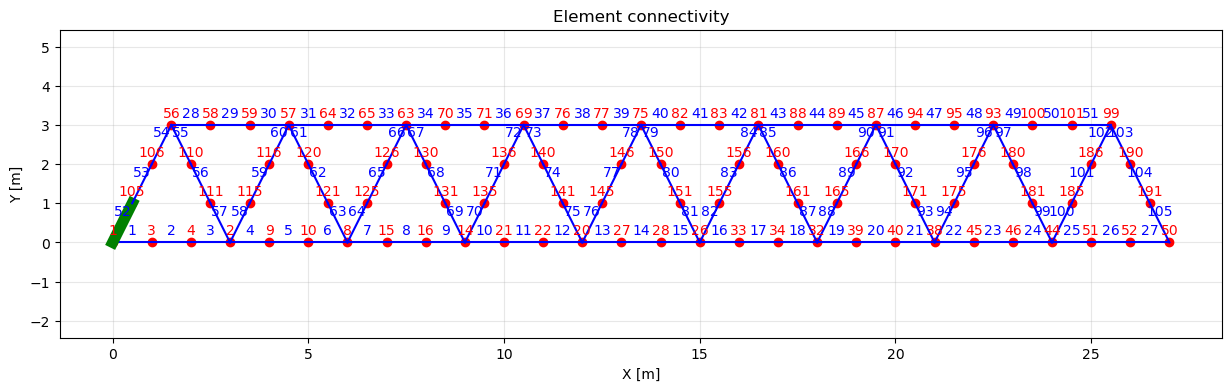

In [17]:
# Plot element connectivity

fig, ax = plt.subplots(figsize=(15, 4))

# Plot nodes
for nodeID, (x, y) in node_coordinates.items():
    ax.plot(x, y, 'ro')
    ax.text(x, y + 0.2, nodeID, color='red', ha='center')

# Plot elements
for elemID, (n1, n2) in element_nodes.items():
    x1, y1 = node_coordinates[n1]
    x2, y2 = node_coordinates[n2]
    
    if elemID == str(crit_element_ID):
        ax.plot([x1, x2], [y1, y2], 'g-', linewidth=8)
    else:
        ax.plot([x1, x2], [y1, y2], 'b-')
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(xm, ym + 0.2, f"{elemID}", color='blue', ha='center')

# Formatting
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Element connectivity")
ax.axis('equal')
ax.grid(True, alpha=0.3)

plt.show()

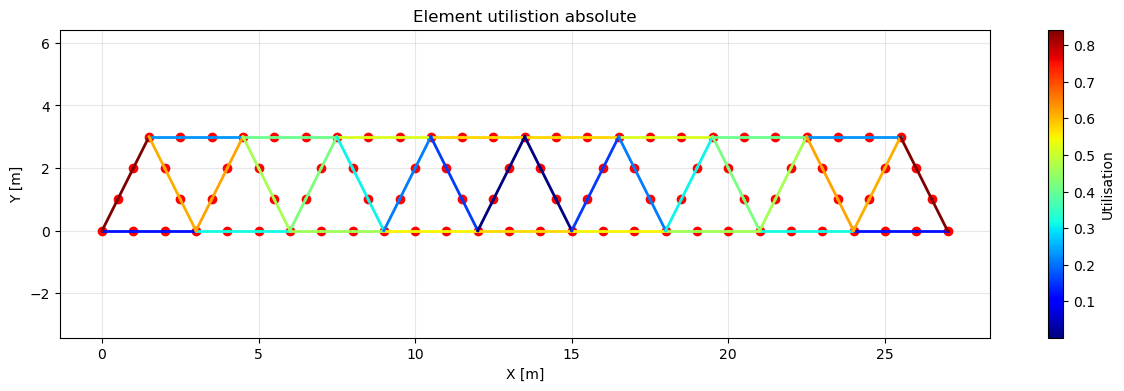

In [18]:
# Plot element utilisation absolute

fig, ax = plt.subplots(figsize=(15, 4))

# Dictionary: element ID -> utilisation
util_dict = dict(zip(element_resistances[ELEMENT_ID].astype(str), element_resistances[UTILISATION_ABSOLUTE]))

# Normalise utilisation values
norm = mcolors.Normalize(vmin=element_resistances[UTILISATION_ABSOLUTE].min(), vmax=element_resistances[UTILISATION_ABSOLUTE].max())

cmap = cm.jet

# Plot nodes
for nodeID, (x, y) in node_coordinates.items():
    ax.plot(x, y, 'ro')

# Plot elements
for elemID, (n1, n2) in element_nodes.items():
    x1, y1 = node_coordinates[n1]
    x2, y2 = node_coordinates[n2]
    
    util = util_dict.get(elemID, None)
    color = cmap(norm(util))
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2)

# Add colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Utilisation")

# Formatting
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Element utilistion absolute")
ax.axis('equal')
ax.grid(True, alpha=0.3)

plt.show()

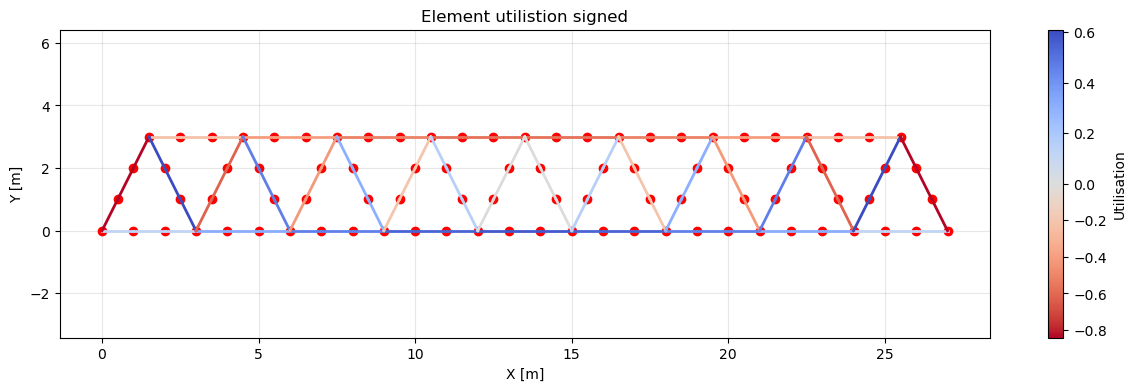

In [19]:
# Plot element utilisation signed

fig, ax = plt.subplots(figsize=(15, 4))

# Dictionary: element ID -> utilisation
util_dict = dict(zip(element_resistances[ELEMENT_ID].astype(str), element_resistances[UTILISATION_SIGNED]))

# Normalise utilisation values
norm = mcolors.Normalize(vmin=element_resistances[UTILISATION_SIGNED].min(), vmax=element_resistances[UTILISATION_SIGNED].max())

# Ensure 0 is mapped to the centre (white) of the colormap
norm = TwoSlopeNorm(
    vmin=element_resistances[UTILISATION_SIGNED].min(), 
    vcenter=0, 
    vmax=element_resistances[UTILISATION_SIGNED].max()
)

cmap = cm.coolwarm_r

# Plot nodes
for nodeID, (x, y) in node_coordinates.items():
    ax.plot(x, y, 'ro')

# Plot elements
for elemID, (n1, n2) in element_nodes.items():
    x1, y1 = node_coordinates[n1]
    x2, y2 = node_coordinates[n2]
    
    util = util_dict.get(elemID, None)
    color = cmap(norm(util))
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2)

# Add colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Utilisation")

# Formatting
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Element utilistion signed")
ax.axis('equal')
ax.grid(True, alpha=0.3)

plt.show()